# Notebook 4 (V4_3) — Bubble-Existence Diagnostics (Theorem 1)

**V4_3 Markov-equilibrium setup (Branch Reduction Lemma).** V4_3 Lemma
`lem_branch_reduction` (line 1344) shows that, fixing the history
$z_0 = \cdots = z_{t-1} = u$, the date-$t$ branch values $q_t^z$,
$d_t^z$, and the kernels $\mathcal M_{t-1,t}^z$ are obtained by
evaluating the Markov equilibrium functions at the two successor states
$s_t^u$, $s_t^b$. The date-$(t-1)$ portfolio choices $\omega_{t-1},
\theta_{t-1}$ are common across branches. This is the rigorous
justification for the branch-indexed objects used in Theorem 1; it
replaces the placeholder branch-dependence assumption from V9.

**V4_3 Theorem 1** (`thm_bubble_characterization`, line 1382) under
Assumptions `ass_regime_switch`, `ass_regular_kernel` (line 1145), and
`prop_balanced_growth_primitives` (line 986): if $z_0 = u$, there is a
bubble in the per-variety US stock at date 0 if and only if
$$
(1a) \quad \sum_{t=1}^{\infty} \frac{d_t^u}{q_t^u} < \infty,
\qquad
(1b) \quad \sum_{t=1}^{\infty} \frac{q_t^b + d_t^b}{q_t^u}
                                \left(\frac{C_t^u}{C_t^b}\right)^\gamma < \infty.
$$
(V4_3 eqs. `thm_cond_1a`, `thm_cond_1b`, line 1385–1387.)

**Production-side mechanism.** Under V4_3 primitives
(`ass_absorbing_bg_technology_primitives`, line 915; `psi_US_def`,
line 942; `ass_regular_kernel`, line 1145), Lemma `lem_prod_orders` and the
proof of `thm_prod_sufficient` give the relevant **one-sided** orders:
- $\varphi_{US,t}^u \lesssim N_{US,t}^{-\psi_{US}/\rho_{US}}$ with
  $\psi_{US} = (\xi_u - \nu_u)(\rho_{US} - 1)$ ⇒ (1a) holds (geometric).
  (V4_3 eq. `phi_u_upper_order`: a one-sided **upper** bound — $\varphi_{US,t}^u$
  is an equilibrium object, so only $\lesssim$ is provable.)
- $q_t^u \asymp e_t^u/N_{US,t}$ with $e_t^u \gtrsim N_{US,t}^{\nu_u}$
  (so $q_t^u \gtrsim N_{US,t}^{\nu_u-1}$),
  $q_t^b + d_t^b \asymp N_{US,t}^{\nu_b - 1}$,
  $C_t^b \asymp N_{US,t}^{\nu_b}$ and $C_t^u \gtrsim N_{US,t}^{\nu_u}$ ⇒ the (1b)
  summand is **bounded above by** $N_{US,t}^{(\nu_b - \nu_u)(1-\gamma)}$, which
  sums when $\nu_u > \nu_b$ and $\gamma < 1$ (V4_3 `thm_prod_sufficient` proof).

Hence under those primitives the per-variety US stock contains a
bubble at date 0.

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryProductionOLG.jl")
using Plots, LaTeXStrings, Printf
gr()


  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


Plots.GRBackend()

In [2]:
p = ProductionParams(T_max=100)   # HKT-matched defaults; solvable to T≈100+
result = run_production_simulation(p; verbose=true)

@printf("u-branch converged: %s   max ‖F_u‖ = %.2e\n",
        result.branch_converged, result.max_u_residual)
@printf("V4_3 equity-weight min slack: %.4e   ok=%s\n",
        result.diagnostics.equity_weight_min, result.diagnostics.equity_weights_ok)
if !result.branch_converged || !(result.max_u_residual < 1e-5)
    @warn "u-branch did not meet the residual tolerance; downstream diagnostics/exports are provisional." max_u_residual=result.max_u_residual
end


Calibrating ν_b for common world growth (V4_3 G_b = G_W)...
  iter  1: ν_b -> 0.094292 (Δ=5.71e-03), ‖F‖=2.15e-12
  iter  2: ν_b -> 0.090367 (Δ=3.93e-03), ‖F‖=4.78e-13
  iter  3: ν_b -> 0.087667 (Δ=2.70e-03), ‖F‖=1.06e-13
  iter  4: ν_b -> 0.085810 (Δ=1.86e-03), ‖F‖=2.36e-14
  iter  5: ν_b -> 0.084532 (Δ=1.28e-03), ‖F‖=5.38e-15
  iter  6: ν_b -> 0.083654 (Δ=8.78e-04), ‖F‖=9.36e-16
  iter  7: ν_b -> 0.083050 (Δ=6.04e-04), ‖F‖=2.22e-16
  iter  8: ν_b -> 0.082634 (Δ=4.16e-04), ‖F‖=4.44e-16
  iter  9: ν_b -> 0.082348 (Δ=2.86e-04), ‖F‖=2.78e-16
  iter 10: ν_b -> 0.082152 (Δ=1.97e-04), ‖F‖=1.35e-16
  iter 11: ν_b -> 0.082017 (Δ=1.35e-04), ‖F‖=4.86e-10
  iter 12: ν_b -> 0.081924 (Δ=9.30e-05), ‖F‖=2.30e-10
  iter 13: ν_b -> 0.081860 (Δ=6.40e-05), ‖F‖=1.09e-10
  iter 14: ν_b -> 0.081816 (Δ=4.40e-05), ‖F‖=5.15e-11
  iter 15: ν_b -> 0.081785 (Δ=3.03e-05), ‖F‖=2.43e-11
  iter 16: ν_b -> 0.081765 (Δ=2.08e-05), ‖F‖=1.15e-11
  iter 17: ν_b -> 0.081750 (Δ=1.43e-05), ‖F‖=5.45e-12
  iter 18: ν_b -> 0.08

┌ Warning: Forward-backward did not fully converge after 30 iters.
└ @ Main ~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/TwoCountryProductionOLG.jl:1216


Computing bubble diagnostics...
  u-branch converged: true   max ‖F_u‖ = 3.94e-08

══════ V4_3 PRODUCTION-ECONOMY DIAGNOSTICS ══════
  Condition (1a) converges: false   (Σ d^u/q^u  = 5.668957)
  Condition (1b) converges: false   (Σ branch   = 98.573954)
  Geometric-tail (1a): ratio=0.9580  converges=true  Σ_∞=5.832870
  Geometric-tail (1b): ratio=0.9894  converges=true  Σ_∞=161.600374
  BUBBLE EXISTS: true  (tail, regularity, and residual checks)
  Total leakage Σ a_t = 47.914937
  V4_3 ass_regular_kernel  Ψ_t > 0: true  (min Ψ = 9.8357e-01)
  V4_3 ass_interior_equity_weights: true  (min slack = 2.4448e-02)
u-branch converged: true   max ‖F_u‖ = 3.94e-08
V4_3 equity-weight min slack: 2.4448e-02   ok=true


## 1. Theorem 1 Conditions

In [3]:
diag = result.diagnostics
T = p.T_max
tt = 1:T

println("═══ V4_3 THEOREM 1 DIAGNOSTICS ═══")
@printf("  Cond (1a) Σ d^u/q^u   = %.6f  (fixed-window converges: %s)\n",
        diag.cum_1a[end], diag.cond_1a_converges)
@printf("  Cond (1b) Σ branch    = %.6f  (fixed-window converges: %s)\n",
        diag.cum_1b[end], diag.cond_1b_converges)
# Geometric-tail certification: fits the summand's asymptotic decay ratio r and,
# if r<1, reports the extrapolated infinite sum Σ_∞ = Σ_partial + cond_T·r/(1-r).
# This certifies the Theorem-1 conditions from the finite solved path, sidestepping
# the (much longer) horizon the fixed-window "tail<1%" rule needs for slow decay.
@printf("  Cond (1a) geom-tail   : ratio=%.4f  converges=%s  Σ_∞=%.6f\n",
        diag.ratio_1a, diag.geom_1a_converges, diag.sum_inf_1a)
@printf("  Cond (1b) geom-tail   : ratio=%.4f  converges=%s  Σ_∞=%.6f\n",
        diag.ratio_1b, diag.geom_1b_converges, diag.sum_inf_1b)
@printf("  Total leakage Σ a_t   = %.6f\n", diag.cum_a_t[end])
@printf("  BUBBLE EXISTS         : %s  (tail, regularity, and residual checks)\n", diag.bubble_exists)
@printf("  V4_3 ass_regular_kernel  Ψ_t > 0: %s  (min Ψ = %.4e)\n",
        diag.psi_ok, diag.psi_min)

═══ V4_3 THEOREM 1 DIAGNOSTICS ═══
  Cond (1a) Σ d^u/q^u   = 5.668957  (fixed-window converges: false)
  Cond (1b) Σ branch    = 98.573954  (fixed-window converges: false)
  Cond (1a) geom-tail   : ratio=0.9580  converges=true  Σ_∞=5.832870
  Cond (1b) geom-tail   : ratio=0.9894  converges=true  Σ_∞=161.600374
  Total leakage Σ a_t   = 47.914937
  BUBBLE EXISTS         : true  (tail, regularity, and residual checks)
  V4_3 ass_regular_kernel  Ψ_t > 0: true  (min Ψ = 9.8357e-01)


## 2. Per-Period Decay Rates

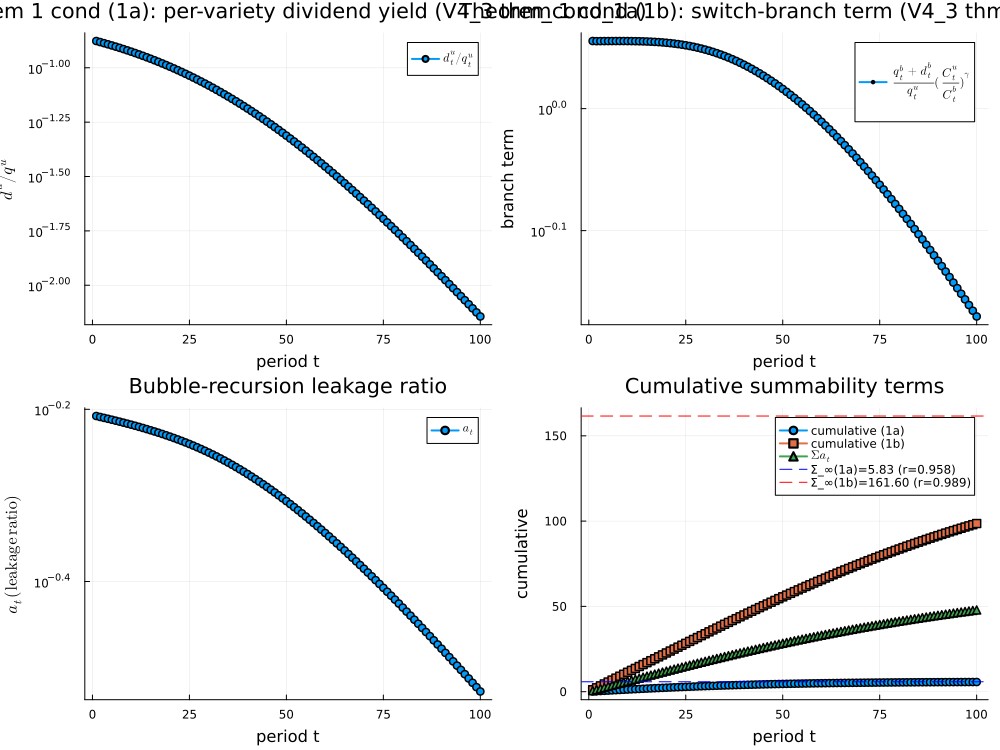

In [4]:
p1 = plot(tt, diag.cond_1a, lw=2, marker=:circle, label=L"d_t^u/q_t^u",
          xlabel="period t", ylabel=L"d^u/q^u", yscale=:log10,
          title="Theorem 1 cond (1a): per-variety dividend yield (V4_3 thm_cond_1a)")

p2 = plot(tt, diag.cond_1b, lw=2, marker=:circle,
          label=L"\frac{q_t^b+d_t^b}{q_t^u}(\frac{C_t^u}{C_t^b})^{\gamma}",
          xlabel="period t", ylabel="branch term", yscale=:log10,
          title="Theorem 1 cond (1b): switch-branch term (V4_3 thm_cond_1b)")

p3 = plot(tt, diag.a_t, lw=2, marker=:circle, label=L"a_t",
          xlabel="period t", ylabel=L"a_t\,(\mathrm{leakage\,ratio})", yscale=:log10,
          title="Bubble-recursion leakage ratio")

p4 = plot(tt, diag.cum_1a, lw=2, marker=:circle, label="cumulative (1a)",
          xlabel="period t", ylabel="cumulative",
          title="Cumulative summability terms")
plot!(p4, tt, diag.cum_1b, lw=2, marker=:square, label="cumulative (1b)")
plot!(p4, tt, diag.cum_a_t, lw=2, marker=:utriangle, label=L"\Sigma a_t")
# Geometric-tail extrapolation: the cumulative (1a)/(1b) curves asymptote to the
# dashed Σ_∞ levels (finite ⇔ summand decays at ratio r<1 ⇒ Theorem-1 condition holds).
isfinite(diag.sum_inf_1a) && hline!(p4, [diag.sum_inf_1a], ls=:dash, lc=:blue,
        label=@sprintf("Σ_∞(1a)=%.2f (r=%.3f)", diag.sum_inf_1a, diag.ratio_1a))
isfinite(diag.sum_inf_1b) && hline!(p4, [diag.sum_inf_1b], ls=:dash, lc=:red,
        label=@sprintf("Σ_∞(1b)=%.2f (r=%.3f)", diag.sum_inf_1b, diag.ratio_1b))

plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 750))

## 3. φ-Decay vs. the V4_3 Upper Bound

By V4_3 Lemma `lem_prod_orders` (eq. `phi_u_upper_order`),
$\varphi_{US,t}^u \lesssim N_{US,t}^{-\psi_{US}/\rho_{US}}$ — a one-sided
**upper** bound only (the two-sided $\asymp$ is not provable, since
$\varphi_{US,t}^u$ is an equilibrium object). We compare the empirical decay
rate against this bound; the empirical exponent approaches
$\psi_{US}/\rho_{US}$ from below as $N_{US,t}$ grows (see
`07_v9_assumption_checks.ipynb`).

V4_3 upper-bound exponent (lem_prod_orders): -ψ_US/ρ_US = -0.2500
Empirical slope of log(φ_US) vs log(N_US): -0.2134
V4_3 upper-bound slope (lem_prod_orders):  -0.2500
⇒ φ_US^u decays SLOWER than the bound on the finite path (|slope| < ψ/ρ),
  consistent with the one-sided ≲ (the bound is approached from below).


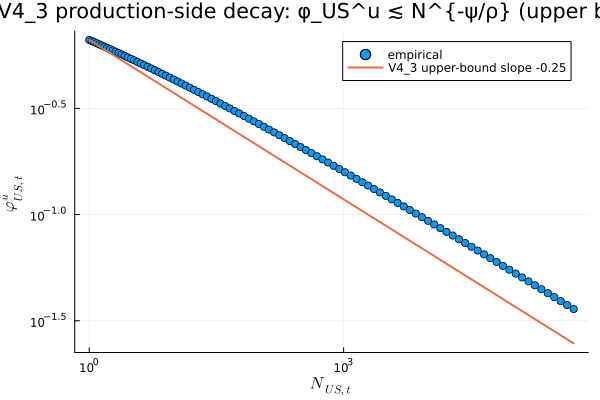

In [5]:
φ_US = [result.u_path[t].φ_US for t in tt]
N_US = [result.u_path[t].N_US for t in tt]

ψ_US = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
decay_pred = ψ_US / p.ρ_US
@printf("V4_3 upper-bound exponent (lem_prod_orders): -ψ_US/ρ_US = -%.4f\n", decay_pred)

# Empirical decay rate via log-log regression
logN = log.(N_US[2:end] ./ N_US[1])
logφ = log.(φ_US[2:end] ./ φ_US[1])
slope_emp = (sum(logN .* logφ) / sum(logN.^2))   # zero-intercept fit
@printf("Empirical slope of log(φ_US) vs log(N_US): %.4f\n", slope_emp)
@printf("V4_3 upper-bound slope (lem_prod_orders):  -%.4f\n", decay_pred)
@printf("⇒ φ_US^u decays SLOWER than the bound on the finite path (|slope| < ψ/ρ),\n")
@printf("  consistent with the one-sided ≲ (the bound is approached from below).\n")

scatter(N_US, φ_US, label="empirical", xscale=:log10, yscale=:log10,
        xlabel=L"N_{US,t}", ylabel=L"\varphi_{US,t}^u",
        title="V4_3 production-side decay: φ_US^u ≲ N^{-ψ/ρ} (upper bound)")
plot!(N_US, φ_US[1] .* (N_US ./ N_US[1]).^(-decay_pred), lw=2,
      label="V4_3 upper-bound slope -$(round(decay_pred, digits=3))")

## 4. Per-Variety vs. Aggregate Price-Dividend Ratios

V4_3 distinguishes per-variety from aggregate objects.
Per-variety ratio:
$$
\frac{q_{US,t}^u}{d_{US,t}^u}
= \frac{1}{a_{US}\,\frac{1-\vartheta_{US}}{\vartheta_{US}}\,\varphi_{US,t}^u H_{US}}
\to \infty.
$$
Aggregate ratio (V4_3 eqs. `country_stock_aggregation`,
`country_dividend_formula`):
$$
\frac{\mathcal Q_{US,t}}{\mathcal D_{US,t}}
= \frac{N_{US,t+1}}{N_{US,t}} \cdot \frac{q_{US,t}^u}{d_{US,t}^u}
= G_{N,US,t} \cdot \frac{q_{US,t}^u}{d_{US,t}^u},
$$
so the two have the same asymptotic order whenever the knowledge
growth factor is bounded.


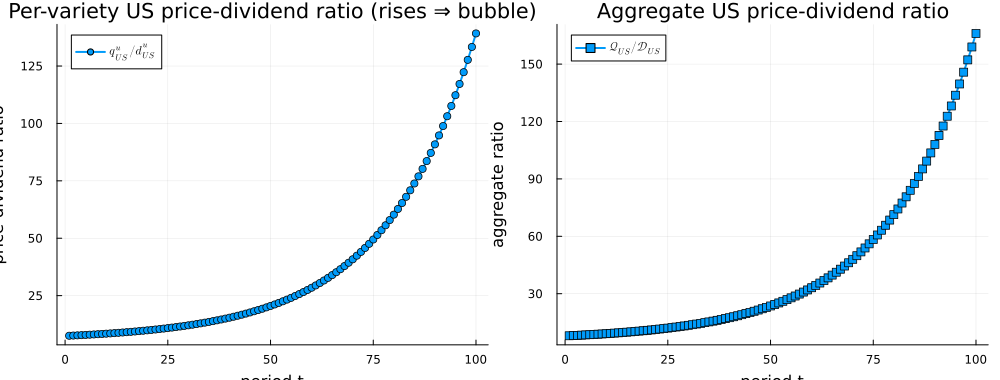

In [6]:
q_US = [result.u_path[t].q_US for t in tt]
d_US = [result.u_path[t].d_US for t in tt]
Q_US = [result.u_path[t].Q_US for t in tt]
D_US = [N_US[t] * d_US[t] for t in tt]
qd_per   = q_US ./ d_US
QD_agg   = Q_US ./ D_US

p1 = plot(tt, qd_per, lw=2, marker=:circle, label=L"q_{US}^u/d_{US}^u",
          xlabel="period t", ylabel="price-dividend ratio",
          title="Per-variety US price-dividend ratio (rises ⇒ bubble)")

p2 = plot(tt, QD_agg, lw=2, marker=:square, label=L"\mathcal{Q}_{US}/\mathcal{D}_{US}",
          xlabel="period t", ylabel="aggregate ratio",
          title="Aggregate US price-dividend ratio")

plot(p1, p2, layout=(1,2), size=(1000, 380))


## 5. Common-World-Growth Diagnostic

V4_3 `ass_absorbing_stationary_equilibrium_selection` (line 947, eq.
980–983) requires the absorbing branch to satisfy $G_b = G_W$. Along
the u-branch, the BGP at each forward state $(N_{US,t+1}^u, N_{W,t+1})$
should remain on this common-growth manifold.


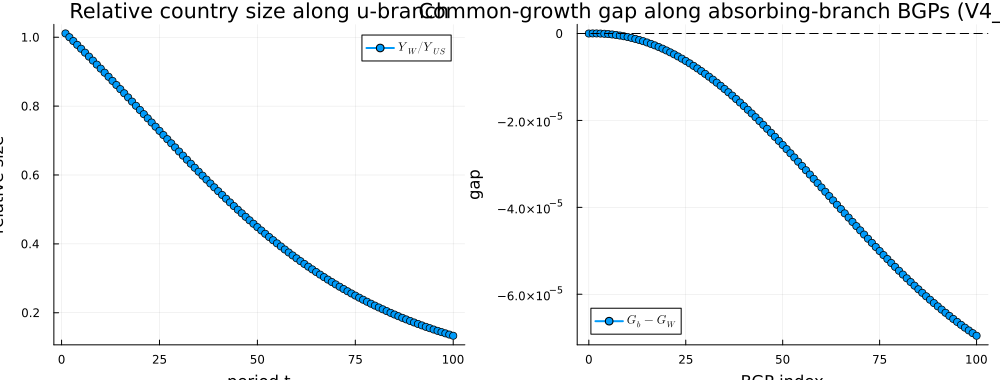

In [7]:
rel_size = [result.u_path[t].Y_W / result.u_path[t].Y_US for t in tt]
p1 = plot(tt, rel_size, lw=2, marker=:circle, label=L"Y_W/Y_{US}",
          xlabel="period t", ylabel="relative size",
          title="Relative country size along u-branch")

# Common-world-growth gap on the absorbing branch
gap = [result.bgp_seq[t].G_N_US^result.params.ν_b - result.bgp_seq[t].G_N_W^result.params.ξ_W for t in 1:T+1]
p2 = plot(0:T, gap, lw=2, marker=:circle, label=L"G_b - G_W",
          xlabel="BGP index", ylabel="gap",
          title="Common-growth gap along absorbing-branch BGPs (V4_3 G_b = G_W)")
hline!(p2, [0.0], ls=:dash, color=:black, label="")

plot(p1, p2, layout=(1,2), size=(1000, 380))


## 6. Regularity-Kernel Diagnostic (V4_3 `ass_regular_kernel`)

V4_3 Theorem 1 requires $\Psi_t > 0$ along the unbalanced branch, where
$$
\Psi_t := 1 - \lambda_t + \phi_t(1-\omega_t),\qquad
\lambda_t = \frac{\eta\theta_t}{\beta}\Upsilon'(\theta_t),\qquad
\phi_t = \frac{\kappa(\omega_t - \bar\omega)}{\beta(1-\theta_t)}.
$$
A **sufficient condition** for $\Psi_t > 0$ under the LogQuadraticCost
(V4_3 eq. line 1175–1183) is
$$
\beta > \frac{\eta\theta_t}{1-\theta_t} + \eta\theta_t^2 + \frac{\kappa\bar\omega}{1-\theta_t}.
$$
The next code cell plots $\Psi_t$ along the u-branch and overlays
the sufficient-condition gap $\beta - \mathrm{RHS}$.


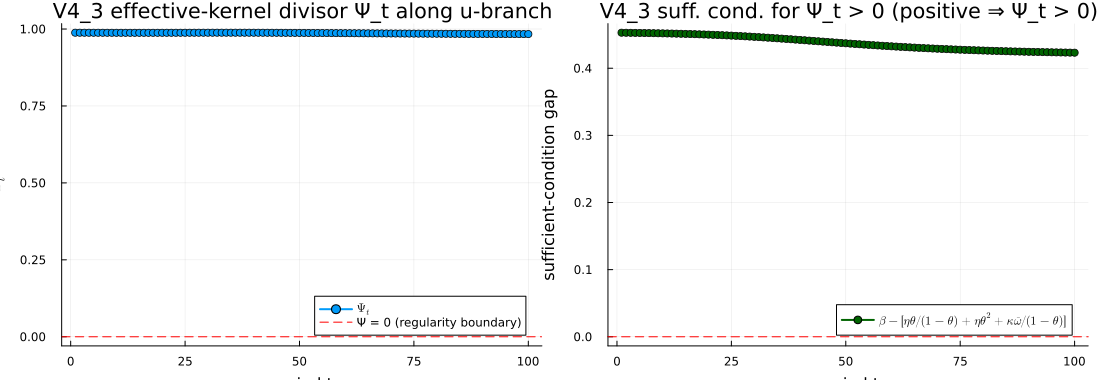

In [8]:
psi_path = [result.u_path[t].Psi for t in tt]
θ_path   = [result.u_path[t].θ for t in tt]
# Sufficient-condition RHS (LogQuadraticCost), V4_3 line 1175–1183
suff_rhs = [p.η * θ_t / (1 - θ_t) + p.η * θ_t^2 + p.κ * p.ω̄ / (1 - θ_t) for θ_t in θ_path]
suff_gap = p.β .- suff_rhs

p1 = plot(tt, psi_path, lw=2, marker=:circle, label=L"\Psi_t",
          xlabel="period t", ylabel=L"\Psi_t",
          title="V4_3 effective-kernel divisor Ψ_t along u-branch")
hline!(p1, [0.0], ls=:dash, color=:red, label="Ψ = 0 (regularity boundary)")

p2 = plot(tt, suff_gap, lw=2, marker=:circle, color=:darkgreen,
          label=L"\beta - [\eta\theta/(1-\theta) + \eta\theta^2 + \kappa\bar\omega/(1-\theta)]",
          xlabel="period t", ylabel="sufficient-condition gap",
          title="V4_3 suff. cond. for Ψ_t > 0 (positive ⇒ Ψ_t > 0)")
hline!(p2, [0.0], ls=:dash, color=:red, label="")

plot(p1, p2, layout=(1,2), size=(1100, 380))


## Summary

- **V4_3 Theorem 1** (`thm_bubble_characterization`, line 1382):
  bubble exists at date 0 iff both summability conditions
  `thm_cond_1a` and `thm_cond_1b` hold.
- **Per-period dividend yield** $d_t^u/q_t^u$ falls geometrically —
  confirming condition (1a).
- **Switch-branch term** $\frac{q_t^b+d_t^b}{q_t^u}(C_t^u/C_t^b)^\gamma$
  is **bounded above by** $N_{US,t}^{(\nu_b-\nu_u)(1-\gamma)}$ — condition (1b)
  (V4_3 `thm_prod_sufficient` proof; a one-sided upper bound).
- **Empirical $\varphi$-decay** stays **below** the V4_3 one-sided upper bound
  $N_{US,t}^{-\psi_{US}/\rho_{US}}$ (Lemma `lem_prod_orders`), approaching its
  slope from below.
- **Per-variety price-dividend ratio** rises monotonically: this is
  the production-side bubble mechanism.
- Under V4_3 common-growth calibration
  (`ass_absorbing_stationary_equilibrium_selection`), relative country
  size stays bounded.
- **Effective-kernel regularity** $\Psi_t > 0$ holds along the u-branch
  for the baseline calibration, satisfying V4_3 `ass_regular_kernel`.

Next notebook: simulate a sample regime path with switch date and
produce the V4_3 transition figures.